# ChurnSense AI: Customer Churn Intelligence System

## Day 1: Data Understanding

In [261]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [262]:
df.shape              # rows and columns


(7043, 21)

In [263]:
df.info()             # column names, data types, non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [264]:
df.describe()         # statistics for numeric columns

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [265]:
df.isnull().sum()     # missing values per column

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [266]:
df.duplicated().sum() # duplicate rows

np.int64(0)

In [267]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [268]:
for col in ["gender", "Partner", "Dependents", "InternetService",
            "Contract", "PaperlessBilling", "PaymentMethod", "TechSupport"]:
    print(col, "->", df[col].unique())

gender -> ['Female' 'Male']
Partner -> ['Yes' 'No']
Dependents -> ['No' 'Yes']
InternetService -> ['DSL' 'Fiber optic' 'No']
Contract -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> ['Yes' 'No']
PaymentMethod -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TechSupport -> ['No' 'Yes' 'No internet service']


### Column Understanding

| Group | Columns |
|---|---|
| Customer profile | gender, SeniorCitizen, Partner, Dependents |
| Account | tenure, Contract, PaperlessBilling, PaymentMethod |
| Services | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Money | MonthlyCharges, TotalCharges |
| Target | Churn |
| ID (not used for prediction) | customerID |

1. Target column: churn
2. Column not used for prediction and why: CustumorID
3. Column with a data type problem:TotalCharges

In [269]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [270]:
df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Data Issue Found: TotalCharges

- TotalCharges is stored as text (object), not a number
- 11 rows have a blank value instead of a number
- All 11 rows have tenure = 0 and Churn = No
- Reason: these are new customers with no billing yet
- Plan for Day 2: convert to numeric and fill the blanks with 0

In [271]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


### Day 1 Notes

1. Rows and columns: (7043, 21)
2. Target column: churn
3. Churn percentage: 26.53698
4. Data issues found: TotalCharges is text with 11 blanks, all tenure = 0 and Churn = No (new customers). Fix on Day 2: convert to numeric, fill with 0.
5. Business questions I want to answer:
   
   - Do month-to-month customers churn more than one-year and two-year customers?
   - Are customers with low tenure more likely to churn?
   - Do customers without tech support churn more?
  

### Problem Statement

**Company:** A telecom provider that loses about 26.536987 % of its customers.
**Problem:** It knows who is leaving, but not why, so its retention efforts are untargeted and costly.
**My solution:** ChurnSense AI predicts each customer's churn probability, explains the main reasons using SHAP, and generates AI-based retention recommendations.

In [272]:
import sqlite3

conn = sqlite3.connect("churnsense.db")
df.to_sql("customers_raw", conn, if_exists="replace", index=False)

pd.read_sql("SELECT COUNT(*) AS total_customers FROM customers_raw", conn)

,total_customers
0,7043


In [273]:
pd.read_sql("""
SELECT Churn, COUNT(*) AS customers
FROM customers_raw
GROUP BY Churn
""", conn)

,Churn,customers
0,No,5174
1,Yes,1869


## Day 2: Cleaning and SQL Analysis


In [274]:
df_clean = df.copy()

In [275]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print(df_clean["TotalCharges"].dtype)
print(df_clean["TotalCharges"].isnull().sum())

float64
0


In [276]:
df_clean["TechSupport"].value_counts()

,count
TechSupport,
No,3473
Yes,2044
No internet service,1526


In [277]:
# 1 if the customer left, 0 if they stayed (easy to average in SQL)
df_clean["churn_flag"] = (df_clean["Churn"] == "Yes").astype(int)

# group customers by how long they have stayed
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
).astype(str)

df_clean[["tenure", "tenure_group", "Churn", "churn_flag"]].head()

,tenure,tenure_group,Churn,churn_flag
0,1,0-12 months,No,0
1,34,25-48 months,No,0
2,2,0-12 months,Yes,1
3,45,25-48 months,No,0
4,2,0-12 months,Yes,1


In [278]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum())
print(df_clean.duplicated().sum())

(7043, 23)
0
0


In [279]:
df_clean.to_sql("customers_clean", conn, if_exists="replace", index=False)

pd.read_sql("SELECT COUNT(*) AS total FROM customers_clean", conn)

,total
0,7043


In [280]:
pd.read_sql("""
SELECT COUNT(*) AS total, SUM(churn_flag) AS churned,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
""", conn)

,total,churned,churn_rate
0,7043,1869,26.5


In [281]:
pd.read_sql("""
SELECT Contract, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY Contract
ORDER BY churn_rate DESC
""", conn)

,Contract,customers,churn_rate
0,Month-to-month,3875,42.7
1,One year,1473,11.3
2,Two year,1695,2.8


In [282]:
pd.read_sql("""
SELECT tenure_group, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY tenure_group
ORDER BY MIN(tenure)
""", conn)

,tenure_group,customers,churn_rate
0,0-12 months,2186,47.4
1,13-24 months,1024,28.7
2,25-48 months,1594,20.4
3,49-72 months,2239,9.5


In [283]:
pd.read_sql("""
SELECT TechSupport, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY TechSupport
ORDER BY churn_rate DESC
""", conn)

,TechSupport,customers,churn_rate
0,No,3473,41.6
1,Yes,2044,15.2
2,No internet service,1526,7.4


In [284]:
pd.read_sql("""
SELECT InternetService, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY InternetService
ORDER BY churn_rate DESC
""", conn)

,InternetService,customers,churn_rate
0,Fiber optic,3096,41.9
1,DSL,2421,19.0
2,No,1526,7.4


In [285]:
pd.read_sql("""
SELECT PaymentMethod, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY PaymentMethod
ORDER BY churn_rate DESC
""", conn)

,PaymentMethod,customers,churn_rate
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


In [286]:
pd.read_sql("""
SELECT SeniorCitizen, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
GROUP BY SeniorCitizen
""", conn)

,SeniorCitizen,customers,churn_rate
0,0,5901,23.6
1,1,1142,41.7


In [287]:
pd.read_sql("""
SELECT Churn, ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
       ROUND(AVG(tenure), 1) AS avg_tenure
FROM customers_clean
GROUP BY Churn
""", conn)

,Churn,avg_monthly,avg_tenure
0,No,61.27,37.6
1,Yes,74.44,18.0


In [288]:
pd.read_sql("""
SELECT ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges END), 0) AS monthly_revenue_lost,
       ROUND(SUM(MonthlyCharges), 0) AS total_monthly_revenue
FROM customers_clean
""", conn)

,monthly_revenue_lost,total_monthly_revenue
0,139131.0,456117.0


In [289]:
pd.read_sql("""
SELECT COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate
FROM customers_clean
WHERE Contract = 'Month-to-month'
  AND tenure <= 12
  AND TechSupport = 'No'
""", conn)

,customers,churn_rate
0,1363,61.0


### Day 2 Findings
1. Contract type: month-to-month customers churn at 42.7%, while two-year customers churn at 2.8%.
2. New customers (0-12 months) churn at 47.4%.
3. Customers with fiber optic internet churn at 41.9%.
4. Electronic check payers churn at 45.3%.
5. The high-risk segment (month-to-month, 12 months or less, no tech support) churns at 61.0%, more than double the overall 26.5%.

In [290]:
df_clean.to_csv("churn_clean.csv", index=False)

## Day 3: EDA and Storytelling

In [291]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# reload only if the session restarted
try:
    df_clean
except NameError:
    df_clean = pd.read_csv("churn_clean.csv")

os.makedirs("charts", exist_ok=True)   # folder to save charts for GitHub

STAY, CHURN = "#2a78d6", "#eb6834"     # blue = stayed, orange = left
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 110,
})

overall = df_clean["churn_flag"].mean() * 100
print(round(overall, 1))

26.5


In [292]:
def churn_rate_bar(column, title, order=None, horizontal=False, fname=None):
    rates = df_clean.groupby(column)["churn_flag"].mean().mul(100).round(1)
    rates = rates.reindex(order) if order else rates.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    if horizontal:
        rates = rates.iloc[::-1]
        bars = ax.barh(rates.index, rates.values, color=CHURN)
        ax.axvline(overall, color=MUTED, linestyle="--", linewidth=1)
        ax.text(overall + 0.8, len(rates) - 0.5, f"Overall {overall:.1f}%",
                color=MUTED, fontsize=9, va="bottom")
        ax.set_xlabel("Churn rate (%)")
        for b, v in zip(bars, rates.values):
            ax.text(v + 0.8, b.get_y() + b.get_height() / 2, f"{v}%",
                    va="center", color=INK)
    else:
        bars = ax.bar(rates.index, rates.values, color=CHURN, width=0.6)
        ax.axhline(overall, color=MUTED, linestyle="--", linewidth=1)
        ax.text(len(rates) - 0.5, overall + 1, f"Overall {overall:.1f}%",
                ha="right", color=MUTED, fontsize=9)
        ax.set_ylabel("Churn rate (%)")
        for b, v in zip(bars, rates.values):
            ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v}%",
                    ha="center", color=INK)

    ax.set_title(title, loc="left")
    plt.tight_layout()
    if fname:
        fig.savefig(f"charts/{fname}")
    plt.show()

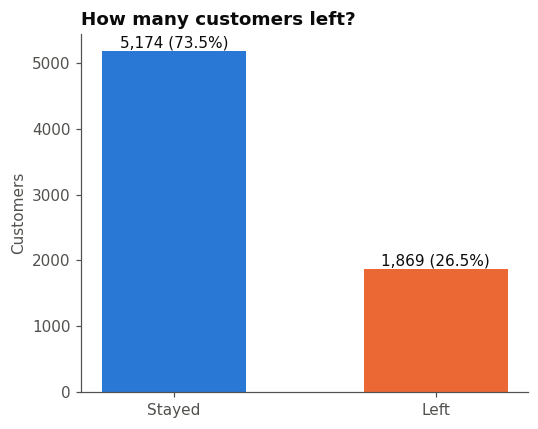

In [293]:
counts = df_clean["Churn"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Stayed", "Left"], [counts["No"], counts["Yes"]],
              color=[STAY, CHURN], width=0.55)
for b, v in zip(bars, [counts["No"], counts["Yes"]]):
    ax.text(b.get_x() + b.get_width() / 2, v + 60,
            f"{v:,} ({v / len(df_clean) * 100:.1f}%)", ha="center", color=INK)
ax.set_title("How many customers left?", loc="left")
ax.set_ylabel("Customers")
plt.tight_layout()
fig.savefig("charts/01_churn_split.png")
plt.show()

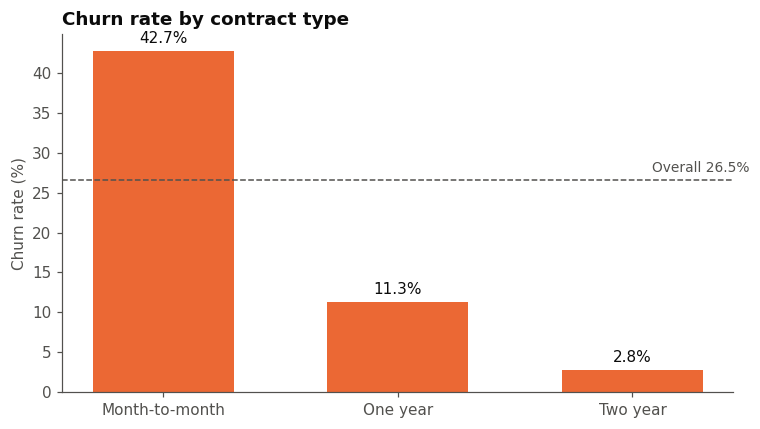

In [294]:
churn_rate_bar("Contract", "Churn rate by contract type",
               order=["Month-to-month", "One year", "Two year"],
               fname="02_contract.png")

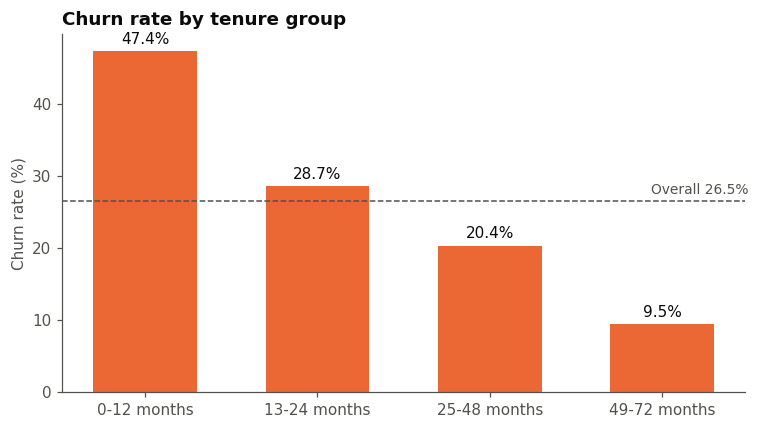

In [295]:
churn_rate_bar("tenure_group", "Churn rate by tenure group",
               order=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
               fname="03_tenure.png")

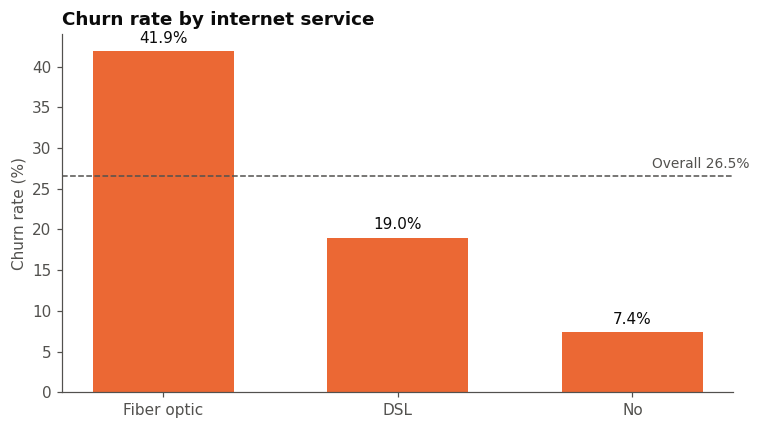

In [296]:
churn_rate_bar("InternetService", "Churn rate by internet service",
               fname="04_internet.png")

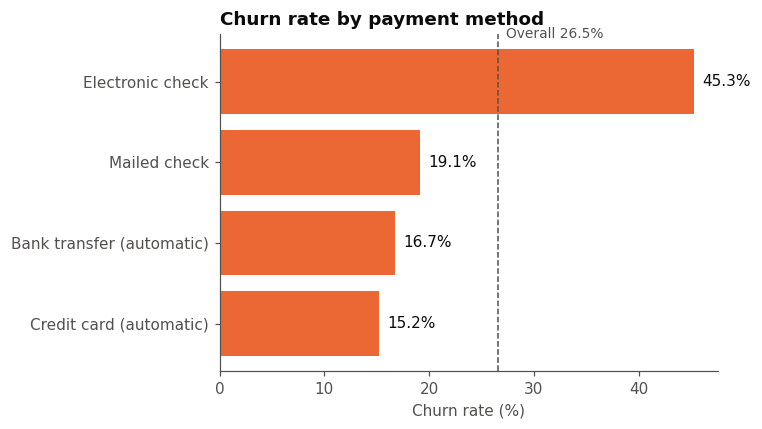

In [297]:
churn_rate_bar("PaymentMethod", "Churn rate by payment method",
               horizontal=True, fname="05_payment.png")


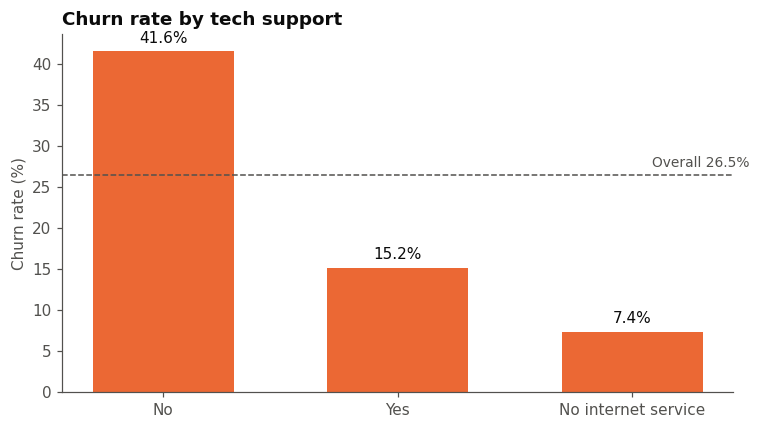

In [298]:
churn_rate_bar("TechSupport", "Churn rate by tech support",
               fname="06_techsupport.png")

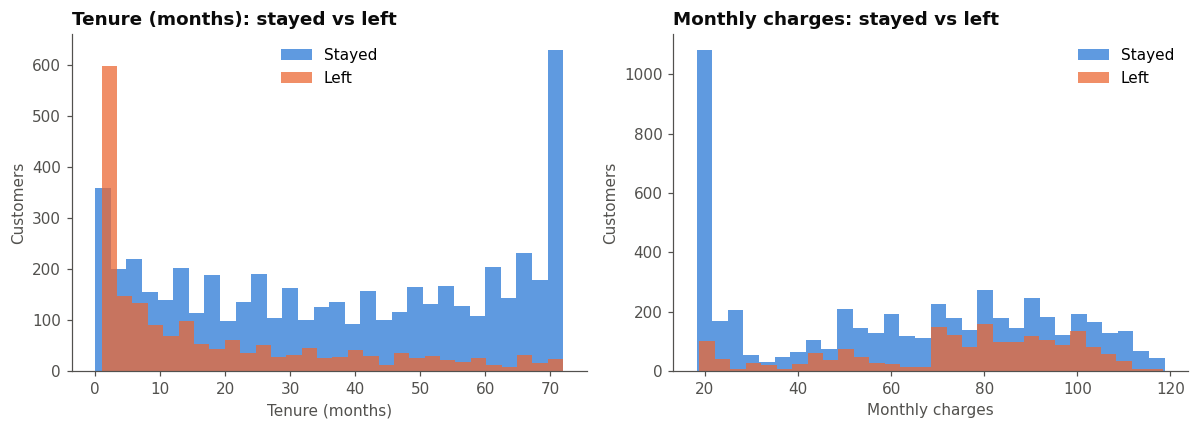

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in zip(axes, ["tenure", "MonthlyCharges"],
                          ["Tenure (months)", "Monthly charges"]):
    ax.hist(df_clean.loc[df_clean.Churn == "No", col], bins=30,
            alpha=0.75, color=STAY, label="Stayed")
    ax.hist(df_clean.loc[df_clean.Churn == "Yes", col], bins=30,
            alpha=0.75, color=CHURN, label="Left")
    ax.set_title(f"{label}: stayed vs left", loc="left")
    ax.set_xlabel(label)
    ax.set_ylabel("Customers")
    ax.legend(frameon=False)
plt.tight_layout()
fig.savefig("charts/07_distributions.png")
plt.show()

In [300]:
df_clean.groupby("Churn")[["tenure", "MonthlyCharges"]].median()

,tenure,MonthlyCharges
Churn,,
No,38.0,64.425
Yes,10.0,79.650


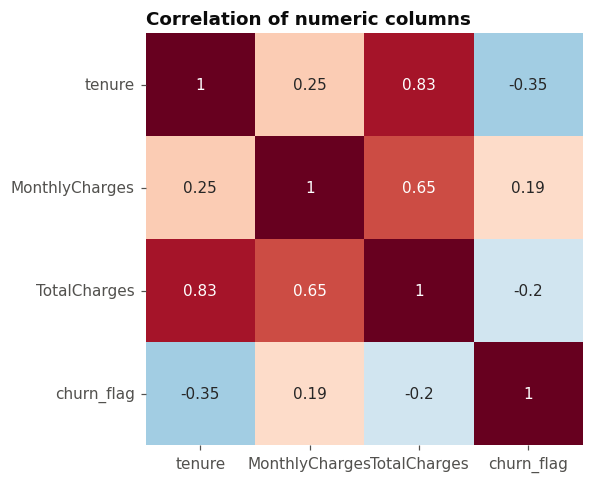

In [301]:
num = df_clean[["tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]]
corr = num.corr().round(2)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, cbar=False)
ax.set_title("Correlation of numeric columns", loc="left")
plt.tight_layout()
fig.savefig("charts/08_correlation.png")
plt.show()

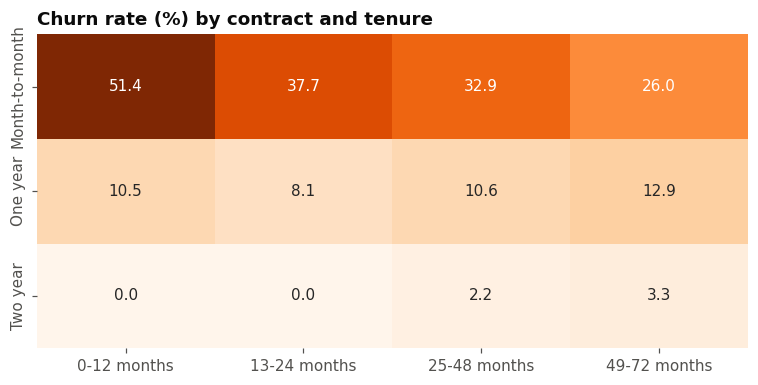

In [302]:
pv = df_clean.pivot_table(index="Contract", columns="tenure_group",
                          values="churn_flag", aggfunc="mean").mul(100).round(1)
pv = pv.reindex(index=["Month-to-month", "One year", "Two year"],
                columns=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

fig, ax = plt.subplots(figsize=(7, 3.6))
sns.heatmap(pv, annot=True, fmt=".1f", cmap="Oranges", ax=ax, cbar=False)
ax.set_title("Churn rate (%) by contract and tenure", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig("charts/09_contract_tenure.png")
plt.show()

### Day 3 Insights
1. Customers leave early: those in their first 12 months churn at 47.4%, and the median tenure of churned customers is 10 months.
2. Contract is the strongest signal: month-to-month 42.7% vs two-year 2.8%.
3. Electronic check payers churn at 45.3%, far above automatic payment methods.
4. Fiber optic customers churn at 41.9%, more than double DSL at 19.0%.
5. Customers with internet but no tech support churn at 41.6% vs 15.2% with it.
6. Churned customers pay more per month (median about 80 vs 64).
7. Even long-tenure month-to-month customers churn at 26.0%, so contract type matters beyond tenure.

In [303]:
os.listdir("charts")

['05_payment.png',
 '10_shap_importance.png',
 '04_internet.png',
 '02_contract.png',
 '11_waterfall_example.png',
 '08_correlation.png',
 '09_contract_tenure.png',
 '06_techsupport.png',
 '07_distributions.png',
 '01_churn_split.png',
 '03_tenure.png']

In [304]:
!zip -r charts.zip charts

updating: charts/ (stored 0%)
updating: charts/05_payment.png (deflated 11%)
updating: charts/04_internet.png (deflated 12%)
updating: charts/02_contract.png (deflated 11%)
updating: charts/08_correlation.png (deflated 13%)
updating: charts/09_contract_tenure.png (deflated 8%)
updating: charts/06_techsupport.png (deflated 11%)
updating: charts/07_distributions.png (deflated 14%)
updating: charts/01_churn_split.png (deflated 15%)
updating: charts/03_tenure.png (deflated 13%)
updating: charts/10_shap_importance.png (deflated 13%)
  adding: charts/11_waterfall_example.png (deflated 8%)


## Day 4: Machine Learning Model

In [305]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import joblib

y = df_clean["churn_flag"]

X = df_clean.drop(columns=["customerID", "Churn", "churn_flag", "tenure_group"])
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(X.shape)

(7043, 30)


In [306]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(round(y_train.mean() * 100, 1), round(y_test.mean() * 100, 1))

(5634, 30) (1409, 30)
26.5 26.5


In [307]:
print(round(1 - y_test.mean(), 3))

0.735


In [308]:
def evaluate(name, model, threshold=0.5):
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {"model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, prob)}

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

results = pd.DataFrame([
    evaluate("Logistic Regression", logreg),
    evaluate("Random Forest", rf),
    evaluate("XGBoost", xgb_model),
]).set_index("model").round(3)

results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.807,0.658,0.567,0.609,0.842
Random Forest,0.806,0.672,0.527,0.591,0.843
XGBoost,0.806,0.670,0.527,0.590,0.846


In [309]:
prob_test = xgb_model.predict_proba(X_test)[:, 1]

rows = []
for t in [0.5, 0.4, 0.35, 0.3, 0.25]:
    pred = (prob_test >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": round(precision_score(y_test, pred), 3),
                 "recall": round(recall_score(y_test, pred), 3)})
pd.DataFrame(rows)

,threshold,precision,recall
0,0.50,0.670,0.527
1,0.40,0.595,0.671
2,0.35,0.552,0.711
3,0.30,0.524,0.765
4,0.25,0.503,0.805


In [310]:
THRESHOLD = 0.30
pred = (prob_test >= THRESHOLD).astype(int)
confusion_matrix(y_test, pred)

array([[775, 260],
       [ 88, 286]])

In [311]:
df_clean["churn_probability"] = (xgb_model.predict_proba(X)[:, 1] * 100).astype(float).round(1)

df_clean["risk_level"] = pd.cut(df_clean["churn_probability"],
                                bins=[-0.1, 30, 60, 100],
                                labels=["Low", "Medium", "High"])

df_clean["in_test_set"] = df_clean.index.isin(X_test.index)

In [312]:
(df_clean[df_clean["in_test_set"]]
    .groupby("risk_level", observed=True)
    .agg(customers=("churn_flag", "count"),
         actual_churn_rate=("churn_flag", lambda s: round(s.mean() * 100, 1))))

,customers,actual_churn_rate
risk_level,,
Low,863,10.2
Medium,353,41.1
High,193,73.1


In [313]:
out = df_clean[["customerID", "Contract", "tenure", "MonthlyCharges",
                "Churn", "churn_probability", "risk_level", "in_test_set"]]
out.to_csv("churn_predictions.csv", index=False)

joblib.dump(xgb_model, "churn_model.joblib")
joblib.dump(list(X.columns), "model_columns.joblib")

out.shape

(7043, 8)

### Day 4 Model Notes
1. Benchmark: a model that always predicts "stay" is 73.5% accurate, so accuracy alone is misleading.
2. Best model: XGBoost with ROC-AUC of 0.846. The three models scored very similarly because a few columns (contract, tenure, internet service) carry most of the signal, so a simple model finds almost all of it.
.
3.  Threshold chosen: 0.30. At this threshold recall is 76.5% and precision is 52.4%.
4. Why I lowered the threshold:missing a customer who leaves costs the company lost monthly revenue, while sending an offer to someone who would have stayed costs very little. Lowering it to 0.30 raised recall from 52.7% to 76.5%.
5. Risk bands on unseen customers: High risk churned 73.1% of the time vs Low risk 10.2%
6. One limitation: the model trained on 80% of customers, so their probabilities are slightly optimistic. I marked the test rows with in_test_set and checked the risk bands on unseen customers only.

## Day 5: Explainability and AI Recommendations

In [314]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X)

shap_df = pd.DataFrame(shap_values.values, columns=X.columns, index=X.index)
shap_df.shape

(7043, 30)

In [315]:
original_cols = [c for c in df.columns if c not in ["customerID", "Churn"]]

def source_column(feature):
    if feature == "TotalCharges":
        return "tenure"
    if feature in original_cols:
        return feature
    for c in original_cols:
        if feature.startswith(c + "_"):
            return c

mapping = {f: source_column(f) for f in X.columns}
shap_grouped = shap_df.T.groupby(mapping).sum().T

FRIENDLY = {"Contract": "Contract", "tenure": "Tenure",
            "InternetService": "Internet service", "PaymentMethod": "Payment method",
            "MonthlyCharges": "Monthly charges", "PaperlessBilling": "Paperless billing",
            "OnlineSecurity": "Online security", "OnlineBackup": "Online backup",
            "DeviceProtection": "Device protection", "TechSupport": "Tech support",
            "StreamingTV": "Streaming TV", "StreamingMovies": "Streaming movies",
            "MultipleLines": "Multiple lines", "PhoneService": "Phone service",
            "Partner": "Has partner", "Dependents": "Has dependents",
            "gender": "Gender", "SeniorCitizen": "Senior citizen"}

shap_grouped.shape

(7043, 18)

tenure             0.68
Contract           0.60
InternetService    0.46
PaymentMethod      0.22
MonthlyCharges     0.18
dtype: float32


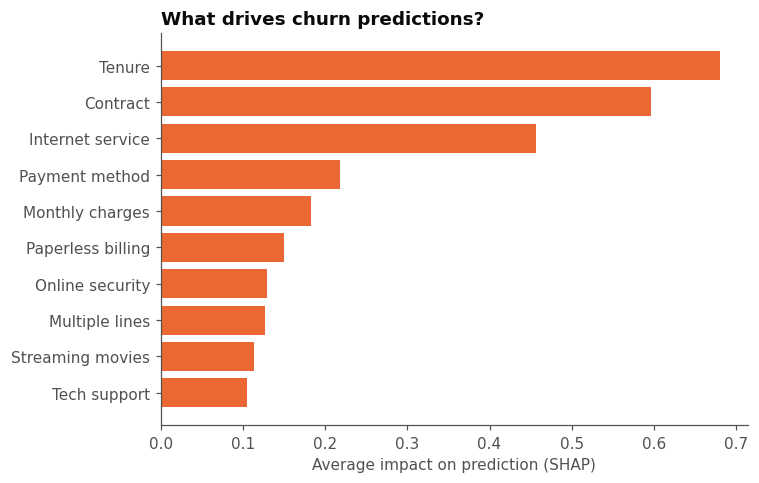

In [316]:
importance = shap_grouped.abs().mean().sort_values(ascending=False)
print(importance.head(5).round(2))

top = importance.head(10).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh([FRIENDLY.get(c, c) for c in top.index], top.values, color=CHURN)
ax.set_title("What drives churn predictions?", loc="left")
ax.set_xlabel("Average impact on prediction (SHAP)")
plt.tight_layout()
fig.savefig("charts/10_shap_importance.png")
plt.show()

In [317]:
def describe(col, value):
    if col == "tenure":
        return f"Tenure: {value} month" + ("" if value == 1 else "s")
    if col == "MonthlyCharges":
        return f"Monthly charges: ${value:.2f}"
    if col == "SeniorCitizen":
        return "Senior citizen" if value == 1 else "Not a senior citizen"
    return f"{FRIENDLY.get(col, col)}: {value}"

def top_reasons(i, n=3):
    row = shap_grouped.loc[i].sort_values(ascending=False)
    row = row[row > 0].head(n)
    return [(col, describe(col, df_clean.loc[i, col])) for col in row.index]

# customers the model never saw during training
test_customers = df_clean[df_clean["in_test_set"]]
example_i = test_customers["churn_probability"].idxmax()
example_id = df_clean.loc[example_i, "customerID"]

top_reasons(example_i)

[('tenure', 'Tenure: 1 month'),
 ('InternetService', 'Internet service: Fiber optic'),
 ('Contract', 'Contract: Month-to-month')]

In [318]:
def action_for(col, value):
    if col == "Contract":
        if value == "Month-to-month":
            return "offer a discounted one-year contract"
        if value == "One year":
            return "offer a renewal benefit for a two-year plan"
    if col == "tenure":
        return "schedule an onboarding check-in call" if value <= 12 else "thank them with a loyalty reward"
    if col == "InternetService" and value == "Fiber optic":
        return "run a fiber service-quality review"
    if col == "TechSupport" and value == "No":
        return "offer a free tech support trial"
    if col == "OnlineSecurity" and value == "No":
        return "offer a free online security trial"
    if col == "PaymentMethod" and value == "Electronic check":
        return "encourage automatic payment with a small discount"
    if col == "MonthlyCharges" and value >= 70:
        return "suggest a better-value bundle"
    return None

def recommend_rule_based(i):
    if df_clean.loc[i, "risk_level"] == "Low":
        return "No retention offer needed now. Keep monitoring."
    actions = []
    for col, _ in top_reasons(i, n=5):
        a = action_for(col, df_clean.loc[i, col])
        if a and a not in actions:
            actions.append(a)
    if not actions:
        return "Assign a retention specialist to check in and understand their concerns."
    text = " and ".join(actions[:2])
    return text[0].upper() + text[1:] + "."

recommend_rule_based(example_i)

'Schedule an onboarding check-in call and run a fiber service-quality review.'

In [319]:
def build_prompt(i):
    r = df_clean.loc[i]
    reasons = "; ".join(text for _, text in top_reasons(i))
    return f"""You are a customer retention analyst at a telecom company.

Customer facts:
- Churn probability: {r['churn_probability']:.0f}%
- Main reasons (from the model): {reasons}

Allowed offers: discounted one-year contract, free tech support trial, free online security trial, onboarding check-in call, automatic-payment discount, plan review.

Write a retention recommendation in at most 2 sentences.
Rules: use only the facts above, do not invent complaints, usage data, percentages, prices or discount amounts, and choose offers only from the allowed list."""

print(build_prompt(example_i))

You are a customer retention analyst at a telecom company.

Customer facts:
- Churn probability: 94%
- Main reasons (from the model): Tenure: 1 month; Internet service: Fiber optic; Contract: Month-to-month

Allowed offers: discounted one-year contract, free tech support trial, free online security trial, onboarding check-in call, automatic-payment discount, plan review.

Write a retention recommendation in at most 2 sentences.
Rules: use only the facts above, do not invent complaints, usage data, percentages, prices or discount amounts, and choose offers only from the allowed list.


In [320]:
!pip install google-genai -q
from google import genai
from google.colab import userdata

def recommend_llm(i, api_key):
    client = genai.Client(api_key=api_key)
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=build_prompt(i),
    )
    return response.text

api_key = userdata.get("GEMINI_API_KEY")
print("Key loaded:", api_key is not None)

Key loaded: True


In [321]:
def recommend_llm(i, api_key):
    try:
        client = genai.Client(api_key=api_key)
        response = client.models.generate_content(
            model="gemini-3.8-flash",
            contents=build_prompt(i),
        )
        return response.text
    except Exception as e:
        # Fallback to our robust rule-based recommendation system if quota or API errors occur
        print(f"[API System Notice: Falling back to rule-based recommendations due to: {type(e).__name__}]")
        return recommend_rule_based(i)

print(recommend_llm(example_i, api_key))

[API System Notice: Falling back to rule-based recommendations due to: ClientError]
Schedule an onboarding check-in call and run a fiber service-quality review.


In [322]:
import time

rows = []
for level in ["High", "Medium"]:
    i = test_customers[test_customers["risk_level"] == level].index[0]
    rows.append({"customerID": df_clean.loc[i, "customerID"],
                 "risk_level": level,
                 "reasons": "; ".join(t for _, t in top_reasons(i)),
                 "rule_based": recommend_rule_based(i),
                 "gemini": recommend_llm(i, api_key)})
    time.sleep(5)

llm_examples = pd.DataFrame(rows)
llm_examples.to_csv("llm_examples.csv", index=False)
llm_examples

[API System Notice: Falling back to rule-based recommendations due to: ClientError]
[API System Notice: Falling back to rule-based recommendations due to: ClientError]


,customerID,risk_level,reasons,rule_based,gemini
0,5129-JLPIS,High,Monthly charges: $105.50; Internet service: Fi...,Suggest a better-value bundle and run a fiber ...,Suggest a better-value bundle and run a fiber ...
1,1452-KIOVK,Medium,Internet service: Fiber optic; Contract: Month...,Run a fiber service-quality review and offer a...,Run a fiber service-quality review and offer a...


In [323]:
def customer_report(customer_id, use_llm=False, api_key=None):
    i = df_clean.index[df_clean["customerID"] == customer_id][0]
    r = df_clean.loc[i]
    print(f"Customer ID: {customer_id}")
    print(f"Churn Probability: {r['churn_probability']:.0f}%  ({r['risk_level']} risk)")
    print("Main Reasons:")
    for _, text in top_reasons(i):
        print(f"  - {text}")
    print("Recommendation (rule-based):", recommend_rule_based(i))
    if use_llm:
        print("AI Recommendation (LLM):", recommend_llm(i, api_key))

customer_report(example_id)

Customer ID: 5178-LMXOP
Churn Probability: 94%  (High risk)
Main Reasons:
  - Tenure: 1 month
  - Internet service: Fiber optic
  - Contract: Month-to-month
Recommendation (rule-based): Schedule an onboarding check-in call and run a fiber service-quality review.


In [324]:
customer_report(example_id, use_llm=True, api_key=api_key)

Customer ID: 5178-LMXOP
Churn Probability: 94%  (High risk)
Main Reasons:
  - Tenure: 1 month
  - Internet service: Fiber optic
  - Contract: Month-to-month
Recommendation (rule-based): Schedule an onboarding check-in call and run a fiber service-quality review.
[API System Notice: Falling back to rule-based recommendations due to: ClientError]
AI Recommendation (LLM): Schedule an onboarding check-in call and run a fiber service-quality review.


In [325]:
for level in ["Medium", "Low"]:
    i = test_customers[test_customers["risk_level"] == level].index[0]
    customer_report(df_clean.loc[i, "customerID"])
    print()

Customer ID: 1452-KIOVK
Churn Probability: 42%  (Medium risk)
Main Reasons:
  - Internet service: Fiber optic
  - Contract: Month-to-month
  - Multiple lines: Yes
Recommendation (rule-based): Run a fiber service-quality review and offer a discounted one-year contract.

Customer ID: 6713-OKOMC
Churn Probability: 18%  (Low risk)
Main Reasons:
  - Contract: Month-to-month
  - Phone service: No
  - Tenure: 10 months
Recommendation (rule-based): No retention offer needed now. Keep monitoring.



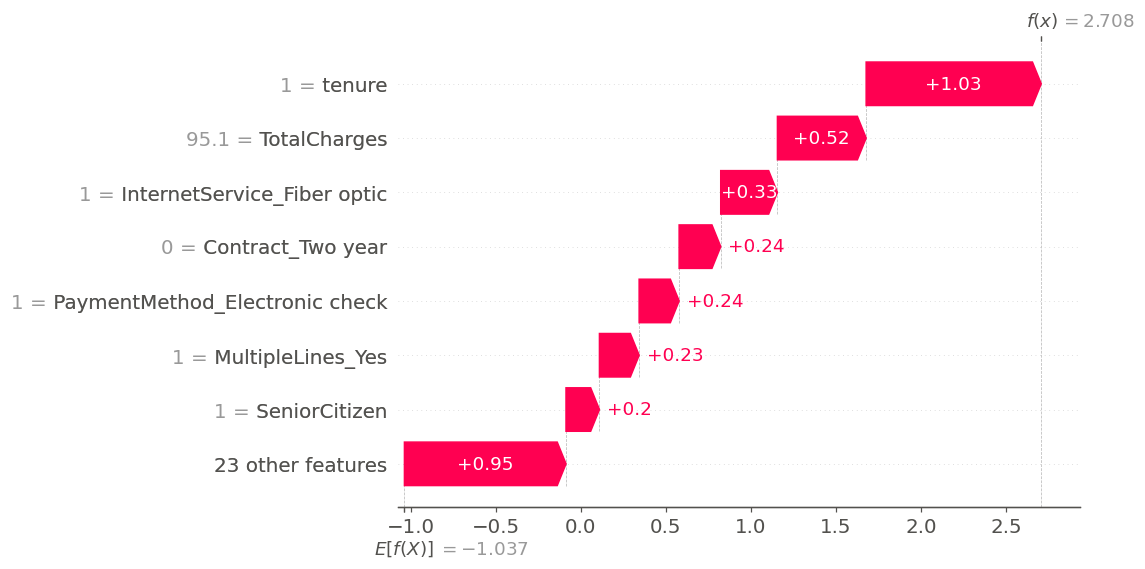

In [326]:
shap.plots.waterfall(shap_values[example_i], max_display=8, show=False)
plt.gcf().savefig("charts/11_waterfall_example.png", bbox_inches="tight")
plt.show()

In [327]:
records = []
for i in df_clean.index:
    reasons = [text for _, text in top_reasons(i)]
    reasons += [""] * (3 - len(reasons))
    records.append({"reason_1": reasons[0], "reason_2": reasons[1],
                    "reason_3": reasons[2],
                    "recommendation": recommend_rule_based(i)})

insights = pd.concat(
    [df_clean[["customerID", "churn_probability", "risk_level", "in_test_set"]],
     pd.DataFrame(records, index=df_clean.index)], axis=1)

insights.to_csv("churn_insights.csv", index=False)
print(insights.shape)
insights["risk_level"].value_counts()

(7043, 8)


,count
risk_level,
Low,4382
Medium,1667
High,994


### Day 5 AI Layer Notes
1. SHAP shows which customer facts (like contract, tenure and internet service) pushed each customer's churn score up or down, so a manager can see why a customer is at risk, not just a number.
2. The three biggest drivers of churn are tenure, contract type and internet service.
3. I merged TotalCharges into tenure because they are highly correlated (0.83) and both describe how long and how much a customer has been with the company, which keeps the reasons simple.
4. Recommendations for all 7,043 customers are generated by rules that map the SHAP reasons to actions. Gemini wrote them for 2 example customers only, using the churn probability and the top 3 SHAP reasons as inputs.
5. I kept the LLM grounded by giving it only the model's facts, an allowed offer list, and rules not to invent complaints, usage data, percentages or prices. I also checked each answer by hand against those rules.
6. One limitation: SHAP explains the model's patterns, not real-world causes, and the data can't prove that an offer will change a customer's mind. The recommendations are suggestions that need human review and a real test before rollout.

## Day 6: Dashboard, GitHub and Wrap-up

In [328]:
dash = pd.concat(
    [df_clean, insights[["reason_1", "reason_2", "reason_3", "recommendation"]]],
    axis=1)
dash["risk_level"] = dash["risk_level"].astype(str)

dash.to_csv("powerbi_data.csv", index=False)
print(dash.shape)

(7043, 30)


In [329]:
for name, d in [("All customers", dash),
                ("Unseen test customers only", dash[dash["in_test_set"]])]:
    high = d[d["risk_level"] == "High"]
    print(name)
    print("  High-risk customers:", len(high))
    print("  Monthly revenue at risk:", round(high["MonthlyCharges"].sum()))
    print("  Annual revenue at risk:", round(high["MonthlyCharges"].sum() * 12))
    print("  Share of monthly revenue:",
          round(high["MonthlyCharges"].sum() / d["MonthlyCharges"].sum() * 100, 1), "%")

All customers
  High-risk customers: 994
  Monthly revenue at risk: 80219
  Annual revenue at risk: 962632
  Share of monthly revenue: 17.6 %
Unseen test customers only
  High-risk customers: 193
  Monthly revenue at risk: 15353
  Annual revenue at risk: 184232
  Share of monthly revenue: 17.0 %
